# VJP CSV Analysis

- CSV を読み込み、時刻ごとにスコアを平均
- 横軸=層、縦軸=平均スコアの遷移をプロット


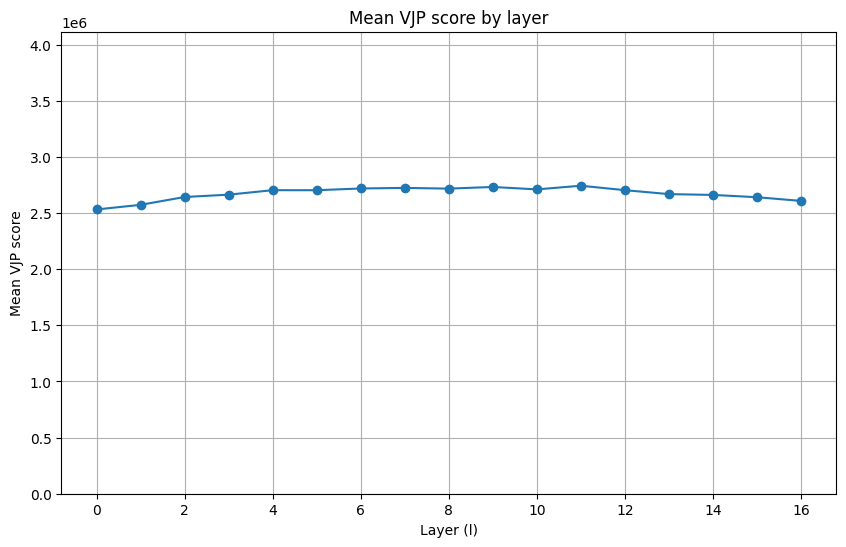

1460


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# VJP CSV のパス
csv_path = Path("/media/dl-box/SSD-SCTU3A/graphcast_data/outputs/vjp/vjp_2022-01-01T000000_2022-12-31T180000_gnn16_20260103T135313Z.csv")

df = pd.read_csv(csv_path)

# time 列を datetime に変換
df["time"] = pd.to_datetime(df["time"].str.replace("Z", "", regex=False))

score_cols = [c for c in df.columns if c.startswith("S_l")]
if len(score_cols) != 17:
    raise ValueError(f"Expected 17 score columns, got {len(score_cols)}")

mean_scores = df[score_cols].mean(axis=0)
layers = [int(c.replace("S_l", "")) for c in score_cols]

plt.figure(figsize=(10, 6))
plt.plot(layers, mean_scores.values, marker="o")
plt.xlabel("Layer (l)")
plt.ylabel("Mean VJP score")
plt.title("Mean VJP score by layer")
ymax = mean_scores.values.max() * 1.5  # 上に余裕を持たせる
plt.ylim(bottom=0, top=ymax)
plt.grid(True)
plt.show()

print(len(df))